In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import time

pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("../dataset")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

SEED = 42
np.random.seed(SEED)


In [2]:
from sentence_transformers import SentenceTransformer
import faiss


c:\Users\Sahil\anaconda3\envs\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_s1 = pd.read_csv(TRAIN_DIR / "train_source1.tsv", sep="\t")
train_s2 = pd.read_csv(TRAIN_DIR / "train_source2.tsv", sep="\t")
train_s3 = pd.read_csv(TRAIN_DIR / "train_source3.tsv", sep="\t")
gt = pd.read_csv(TRAIN_DIR / "train_ground_truth.tsv", sep="\t")

print(f"train_s1={len(train_s1)}  train_s2={len(train_s2)}  train_s3={len(train_s3)}  gt={len(gt)}")


train_s1=2206821  train_s2=5034616  train_s3=5285603  gt=2206821


In [4]:
gt = gt.copy()
gt["n_matches"] = gt["matched_entity_ids"].fillna("").apply(
    lambda x: 0 if x == "" else len(x.split(","))
)

N_PER_BUCKET = 400  # ~400 per match-count bucket -> few thousand S1 entities total

sample_s1_ids = (
    gt.groupby("n_matches", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), N_PER_BUCKET), random_state=SEED))["source1_entity_id"]
)

dev_gt = gt[gt["source1_entity_id"].isin(sample_s1_ids)].copy()
dev_s1 = train_s1[train_s1["entity_id"].isin(sample_s1_ids)].copy()

# pull every true-match ID for the sampled S1 entities, so recall checks are fair
true_match_ids = set()
for ids in dev_gt["matched_entity_ids"].dropna():
    if ids:
        true_match_ids.update(ids.split(","))

# candidate universe: all true matches, PLUS a large random pool of distractors from S2/S3
# (distractors matter — recall@k with zero distractors is unrealistically easy)
N_DISTRACTORS = 60000
s2_distractors = train_s2[~train_s2["entity_id"].isin(true_match_ids)].sample(
    min(N_DISTRACTORS, len(train_s2)), random_state=SEED)["entity_id"]
s3_distractors = train_s3[~train_s3["entity_id"].isin(true_match_ids)].sample(
    min(N_DISTRACTORS, len(train_s3)), random_state=SEED)["entity_id"]

s2_pool_ids = set(true_match_ids) | set(s2_distractors)
s3_pool_ids = set(true_match_ids) | set(s3_distractors)

dev_s2 = train_s2[train_s2["entity_id"].isin(s2_pool_ids)].copy()
dev_s3 = train_s3[train_s3["entity_id"].isin(s3_pool_ids)].copy()

print(f"dev_s1={len(dev_s1)}  dev_s2={len(dev_s2)}  dev_s3={len(dev_s3)}  dev_gt={len(dev_gt)}")


C:\Users\Sahil\AppData\Local\Temp\ipykernel_14528\142559877.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), N_PER_BUCKET), random_state=SEED))["source1_entity_id"]


dev_s1=4437  dev_s2=70733  dev_s3=71674  dev_gt=4437


In [5]:
def pct_non_ascii(df, col):
    return df[col].astype(str).str.contains(r"[^\x00-\x7F]", regex=True).mean()

for name, df in [("S1", train_s1), ("S2", train_s2), ("S3", train_s3)]:
    print(f"{name}: business_name non-ASCII={pct_non_ascii(df, 'business_name'):.2%}  "
          f"business_address non-ASCII={pct_non_ascii(df, 'business_address'):.2%}")


S1: business_name non-ASCII=0.00%  business_address non-ASCII=0.03%
S2: business_name non-ASCII=15.19%  business_address non-ASCII=9.50%
S3: business_name non-ASCII=11.48%  business_address non-ASCII=9.02%


In [6]:
def build_text(name, address, country, include_address=True):
    name = "" if pd.isna(name) else str(name).strip()
    country = "" if pd.isna(country) else str(country).strip()
    if include_address and not pd.isna(address):
        address = str(address).strip()
        return f"{name}, {address}, {country}".strip(", ")
    return f"{name}, {country}".strip(", ")

for df in (dev_s1, dev_s2, dev_s3):
    df["text_combined"] = df.apply(
        lambda r: build_text(r["business_name"], r["business_address"], r["country"]), axis=1)
    df["text_name_only"] = df.apply(
        lambda r: build_text(r["business_name"], None, r["country"], include_address=False), axis=1)
    df["has_address"] = df["business_address"].notna()

dev_s1[["entity_id", "text_combined", "text_name_only", "has_address"]].head()


,entity_id,text_combined,text_name_only,has_address
175,S1-387694500,"Bombay Power Private Limited, No: 32/2, 2Nd Floor, Mcc Towers, Opp To Sigma Soft Tech Park, Whitefield Main Road, Ra...","Bombay Power Private Limited, India",True
518,S1-545370440,"Oliver Springs Urology Precision Care PC, 628 Sleepy Hollow Road, Oliver Springs, TN, US","Oliver Springs Urology Precision Care PC, US",True
524,S1-196054265,"Healy Endocrinology, 30 Coolidge Road, Winchester, MA, US","Healy Endocrinology, US",True
815,S1-38402575,"White Marketing Private Limited, S. No 142/4, Cts No 5102, Fl No 1001, Bld No C, 10Th Floor, Aishwaryam Ventures, Pu...","White Marketing Private Limited, India",True
1109,S1-562441786,"Appleby and Salgado Suma, 11657 Breyman Avenue, Portland, OR, US","Appleby and Salgado Suma, US",True


In [7]:
MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(MODEL_NAME)
print(f"Loaded {MODEL_NAME} — embedding dim: {model.get_sentence_embedding_dimension()}")


c:\Users\Sahil\anaconda3\envs\.venv\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sahil\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\Sahil\anaconda3\envs\.venv\lib\site-packages\huggingface_hub\fil

Loaded paraphrase-multilingual-MiniLM-L12-v2 — embedding dim: 384


C:\Users\Sahil\AppData\Local\Temp\ipykernel_14528\924197374.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Loaded {MODEL_NAME} — embedding dim: {model.get_sentence_embedding_dimension()}")


In [8]:
def embed(texts, batch_size=128):
    return model.encode(
        list(texts), batch_size=batch_size, show_progress_bar=True,
        normalize_embeddings=True,  # so inner product == cosine similarity
        convert_to_numpy=True,
    ).astype("float32")

t0 = time.time()
s2_emb = embed(dev_s2["text_combined"])
s3_emb = embed(dev_s3["text_combined"])
print(f"Embedded S2+S3 combined text in {time.time()-t0:.1f}s")


Batches: 100%|██████████| 560/560 [08:05<00:00,  1.15it/s]


Embedded S2+S3 combined text in 1018.1s


In [9]:
candidate_ids = np.concatenate([dev_s2["entity_id"].values, dev_s3["entity_id"].values])
candidate_emb = np.vstack([s2_emb, s3_emb])

dim = candidate_emb.shape[1]
index = faiss.IndexFlatIP(dim)  # inner product on normalized vectors == cosine similarity
index.add(candidate_emb)
print(f"FAISS index: {index.ntotal} vectors, dim={dim}")


FAISS index: 142407 vectors, dim=384


In [10]:
t0 = time.time()
s1_emb = embed(dev_s1["text_combined"])
print(f"Embedded S1 in {time.time()-t0:.1f}s")

K_MAX = 50
scores, idxs = index.search(s1_emb, K_MAX)
print(f"Search done. scores shape={scores.shape}")


Batches: 100%|██████████| 35/35 [00:30<00:00,  1.14it/s]


Embedded S1 in 30.7s
Search done. scores shape=(4437, 50)


In [11]:
s1_id_list = dev_s1["entity_id"].tolist()
gt_lookup = dict(zip(dev_gt["source1_entity_id"], dev_gt["matched_entity_ids"]))

def recall_at_k(k):
    hit, total = 0, 0
    for row_i, s1_id in enumerate(s1_id_list):
        truth = gt_lookup.get(s1_id)
        if not isinstance(truth, str) or truth == "":
            continue
        true_ids = set(truth.split(","))
        total += len(true_ids)
        retrieved = set(candidate_ids[idxs[row_i, :k]])
        hit += len(true_ids & retrieved)
    return hit / total if total else float("nan")

for k in [5, 10, 15, 20, 30, 50]:
    r = recall_at_k(k)
    print(f"recall@{k:2d} = {r:.2%}   (naive floor: 21.85%)")


recall@ 5 = 61.86%   (naive floor: 21.85%)
recall@10 = 78.28%   (naive floor: 21.85%)
recall@15 = 81.06%   (naive floor: 21.85%)
recall@20 = 82.36%   (naive floor: 21.85%)
recall@30 = 84.09%   (naive floor: 21.85%)
recall@50 = 86.01%   (naive floor: 21.85%)


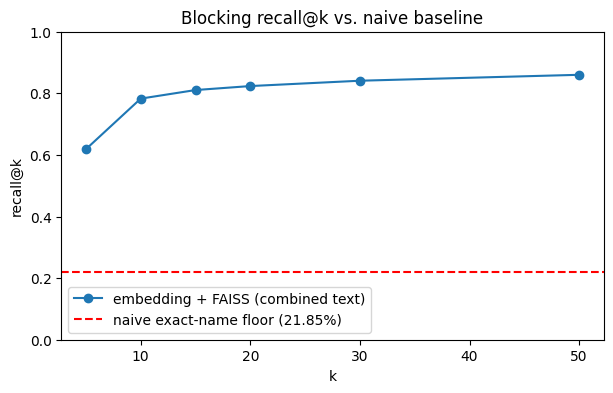

In [12]:
import matplotlib.pyplot as plt

ks = [5, 10, 15, 20, 30, 50]
recalls = [recall_at_k(k) for k in ks]

plt.figure(figsize=(7,4))
plt.plot(ks, recalls, marker="o", label="embedding + FAISS (combined text)")
plt.axhline(0.2185, color="red", linestyle="--", label="naive exact-name floor (21.85%)")
plt.xlabel("k")
plt.ylabel("recall@k")
plt.title("Blocking recall@k vs. naive baseline")
plt.legend()
plt.ylim(0, 1)
plt.show()


In [13]:
def build_addr_text(address, country):
    if pd.isna(address):
        return None
    return f"{str(address).strip()}, {'' if pd.isna(country) else str(country).strip()}".strip(", ")

dev_s2["text_addr_only"] = dev_s2.apply(lambda r: build_addr_text(r["business_address"], r["country"]), axis=1)
dev_s3["text_addr_only"] = dev_s3.apply(lambda r: build_addr_text(r["business_address"], r["country"]), axis=1)
dev_s1["text_addr_only"] = dev_s1.apply(lambda r: build_addr_text(r["business_address"], r["country"]), axis=1)

# name-only index
s2_name_emb = embed(dev_s2["text_name_only"])
s3_name_emb = embed(dev_s3["text_name_only"])
name_candidate_emb = np.vstack([s2_name_emb, s3_name_emb])
name_index = faiss.IndexFlatIP(dim)
name_index.add(name_candidate_emb)

# address-only index — only over rows that actually HAVE an address
s2_has_addr = dev_s2["text_addr_only"].notna()
s3_has_addr = dev_s3["text_addr_only"].notna()
addr_ids = np.concatenate([
    dev_s2.loc[s2_has_addr, "entity_id"].values,
    dev_s3.loc[s3_has_addr, "entity_id"].values,
])
s2_addr_emb = embed(dev_s2.loc[s2_has_addr, "text_addr_only"])
s3_addr_emb = embed(dev_s3.loc[s3_has_addr, "text_addr_only"])
addr_candidate_emb = np.vstack([s2_addr_emb, s3_addr_emb])
addr_index = faiss.IndexFlatIP(dim)
addr_index.add(addr_candidate_emb)

print(f"name index: {name_index.ntotal} vectors | addr index: {addr_index.ntotal} vectors "
      f"({len(dev_s1) - (s2_has_addr.sum()+s3_has_addr.sum())} S2/S3 rows skipped, no address)")


Batches: 100%|██████████| 541/541 [05:58<00:00,  1.51it/s]


name index: 142407 vectors | addr index: 137505 vectors (-133068 S2/S3 rows skipped, no address)


In [17]:
K_EACH = 20  # per-pass k, before union

s1_name_emb = embed(dev_s1["text_name_only"])
name_scores, name_idxs = name_index.search(s1_name_emb, K_EACH)

s1_has_addr = dev_s1["text_addr_only"].notna()
addr_scores = addr_idxs = None
if s1_has_addr.any():
    s1_addr_emb = embed(dev_s1.loc[s1_has_addr, "text_addr_only"])
    addr_scores, addr_idxs = addr_index.search(s1_addr_emb, K_EACH)

def recall_at_k_dual():
    hit, total = 0, 0
    addr_row_map = {orig_i: new_i for new_i, orig_i in enumerate(np.where(s1_has_addr)[0])}
    for row_i, s1_id in enumerate(s1_id_list):
        truth = gt_lookup.get(s1_id)
        if not isinstance(truth, str) or truth == "":
            continue
        true_ids = set(truth.split(","))
        total += len(true_ids)

        retrieved = set(candidate_ids[name_idxs[row_i]])  # name-pass candidates use same S2+S3 order as combined index
        if row_i in addr_row_map and addr_idxs is not None:
            retrieved |= set(addr_ids[addr_idxs[addr_row_map[row_i]]])
        hit += len(true_ids & retrieved)
    return hit / total if total else float("nan")

dual_recall = recall_at_k_dual()
print(f"Dual blocking (name k={K_EACH} + addr k={K_EACH}, unioned): recall = {dual_recall:.2%}")
print(f"Combined-text blocking @ k={2*K_EACH} for comparison: {recall_at_k(2*K_EACH):.2%}")


Batches: 100%|██████████| 35/35 [00:23<00:00,  1.49it/s]


Dual blocking (name k=20 + addr k=20, unioned): recall = 91.29%
Combined-text blocking @ k=40 for comparison: 85.25%


In [18]:
s1_lookup = dev_s1.set_index("entity_id")
s2_lookup = train_s2.set_index("entity_id")
s3_lookup = train_s3.set_index("entity_id")

def lookup_any(eid):
    if eid.startswith("S2-"):
        return s2_lookup.loc[eid]
    return s3_lookup.loc[eid]

misses = []
for row_i, s1_id in enumerate(s1_id_list):
    truth = gt_lookup.get(s1_id)
    if not isinstance(truth, str) or truth == "":
        continue
    true_ids = set(truth.split(","))
    retrieved = set(candidate_ids[idxs[row_i, :K_MAX]])
    missed = true_ids - retrieved
    for m in missed:
        misses.append((s1_id, m))

print(f"Total missed true-matches at k={K_MAX}: {len(misses)}")

import random
random.seed(SEED)
for s1_id, m_id in random.sample(misses, min(10, len(misses))):
    s1_rec = s1_lookup.loc[s1_id]
    m_rec = lookup_any(m_id)
    print(f"S1 [{s1_id}] {s1_rec['business_name']!r} | {s1_rec['business_address']!r}")
    print(f"  MISSED -> [{m_id}] {m_rec['business_name']!r} | {m_rec['business_address']!r}")
    print()


Total missed true-matches at k=50: 3134
S1 [S1-225242270] 'Engelke, Bacon and Geisler Inc' | '2510 Yuma Hills Circle, Crosby, TX'
  MISSED -> [S2-116159611] '#engelkebacon' | '2510 YUMA HILLS CIR, CROSBY, TX'

S1 [S1-345124160] 'Shakti Infotech Private Limited' | 'A-108 Wz-126 Blk A Gali No. 39 Uttam Nagar, Delhi, West Delhi, Delhi'
  MISSED -> [S3-752481592] 'Zetaquo' | 'A-108 Wz-126 Blk A Gali No. 39 Uttam Nagar, Delhi, West Delhi, Delhi'

S1 [S1-428724919] 'Gold Premier Technologies Private Limited' | '361-A, Kottur Road, Suleeswaranpatti Pollachi-642 001, Pollachi, Coimbatore, Tamil Nadu'
  MISSED -> [S2-387444680] 'கோல்டு பிரீமியர் டெக்னாலஜீஸ் பிரைவேட் லிமிடெட்' | '##361-A, KOTTUR ROAD, SULEESWARANPATTI POLLACHI-642 001, POLLACHI, COIMBATORE, Tamil Nadu'

S1 [S1-214425181] 'Empire American Foods' | '1051 Pacific Street, Hempstead, NY'
  MISSED -> [S3-698127699] 'Jaxcirabrix' | 'Pacific St, Baldiwn CDP, New York'

S1 [S1-243083279] 'X 2 G Freight' | '2614 4050, Roy City, UT'
  MISS